# Dataset numbers

Reports the size of the raw UniProt dataset *exactly* as it enters the ToxFam
preprocessing pipeline, by calling `toxfam.data.preprocessing.load_and_prepare_raw`.

That function:
- reads `data/raw/0800.tsv` (toxins) and drops rows without a `Protein families` annotation,
- reads `data/raw/nontox.tsv` (non-toxins) and discards the top 1% longest sequences,
- normalises family-label strings.

The numbers below therefore reflect what subsequent steps (SignalP6, MMseqs2
clustering, splitting) actually receive.

In [1]:
import pandas as pd

from toxfam._paths import raw_dir
from toxfam.data.preprocessing import load_and_prepare_raw

tox, nontox = load_and_prepare_raw()

raw_tox_path = raw_dir() / "0800.tsv"
raw_nontox_path = raw_dir() / "nontox.tsv"
raw_tox = pd.read_csv(raw_tox_path, sep="\t")
raw_nontox = pd.read_csv(raw_nontox_path, sep="\t")

In [2]:
import hashlib
import json

import numpy as np

from toxfam._paths import intermediate_dir, processed_dir

# --- Stage 1: raw TSVs ---
n_raw_tox = len(raw_tox)
n_raw_nontox = len(raw_nontox)
n_raw_tox_family_strings = raw_tox["Protein families"].dropna().nunique()

# --- Stage 2: drop toxins without "Protein families" + normalize family labels ---
# (this is what load_and_prepare_raw does internally, before touching nontox)
n_tox_after_dropna = int(raw_tox["Protein families"].notna().sum())
n_tox_after_norm = len(tox)
n_tox_families_after_norm = tox["Protein families"].nunique()

# --- Stage 3: top-1% longest non-toxin filter (applied on RAW, pre-SP6 lengths) ---
nontox_raw_len = raw_nontox["Sequence"].str.len()
k_top = int(np.ceil(len(raw_nontox) * 0.01))
length_cutoff_aa = int(nontox_raw_len.nlargest(k_top).min())
n_nontox_after_filter = len(nontox)
n_nontox_dropped = n_raw_nontox - n_nontox_after_filter

# --- Stage 4: SignalP6 mature-sequence extraction (counts unchanged, sequences shortened) ---
sp6_cache_path = intermediate_dir() / "sp6" / "sp6_cache.json"
sp6_cache: dict[str, str | None] = (
    json.loads(sp6_cache_path.read_text()) if sp6_cache_path.exists() else {}
)


def _md5(s: str) -> str:
    return hashlib.md5(s.encode()).hexdigest()


def _count_sp6_trimmed(df: pd.DataFrame) -> int:
    n = 0
    for seq in df["Sequence"]:
        mature = sp6_cache.get(_md5(seq))
        if mature is not None and mature != seq:
            n += 1
    return n


n_tox_sp6_trimmed = _count_sp6_trimmed(tox)
n_nontox_sp6_trimmed = _count_sp6_trimmed(nontox)

# --- Stage 5: MMseqs2 90% clustering → representatives (+ family <10 → "other") ---
reps_all = pd.read_csv(
    intermediate_dir() / "mmseqs" / "representatives" / "all.csv"
)
reps_tox = pd.read_csv(
    intermediate_dir() / "mmseqs" / "representatives" / "tox.csv"
)
n_reps_tox = len(reps_tox)
n_reps_nontox = len(reps_all) - n_reps_tox
n_reps_tox_families = reps_tox["Protein families"].nunique()

# --- Stage 6: stratified train/val/test splits → final training_data.csv ---
training_data = pd.read_csv(processed_dir() / "training_data.csv")
is_nontox_final = training_data["Protein families"] == "nontox"
n_final_tox = int((~is_nontox_final).sum())
n_final_nontox = int(is_nontox_final.sum())
n_final_tox_families = (
    training_data.loc[~is_nontox_final, "Protein families"].nunique()
)

print(f"Non-toxin length cutoff (top-1% filter on RAW lengths): <= {length_cutoff_aa} aa")
print(f"  -> drops {n_nontox_dropped} sequences (raw len > {length_cutoff_aa})")
print()

summary = pd.DataFrame(
    [
        ("1. raw TSV",                            n_raw_tox,           n_raw_nontox,           n_raw_tox + n_raw_nontox,           n_raw_tox_family_strings,   "distinct raw `Protein families` strings"),
        ("2a. drop toxins without family",        n_tox_after_dropna,  n_raw_nontox,           n_tox_after_dropna + n_raw_nontox,  None,                       f"-{n_raw_tox - n_tox_after_dropna} toxin"),
        ("2b. normalize toxin family labels",     n_tox_after_norm,    n_raw_nontox,           n_tox_after_norm + n_raw_nontox,    n_tox_families_after_norm,  "regex/conotoxin map + <10 -> 'other'"),
        (f"3. drop top 1% longest non-toxin",     n_tox_after_norm,    n_nontox_after_filter,  n_tox_after_norm + n_nontox_after_filter, n_tox_families_after_norm, f"cutoff <= {length_cutoff_aa} aa; -{n_nontox_dropped} nontox"),
        ("4. SignalP6 mature-seq extraction",     n_tox_after_norm,    n_nontox_after_filter,  n_tox_after_norm + n_nontox_after_filter, n_tox_families_after_norm, f"trims {n_tox_sp6_trimmed} tox / {n_nontox_sp6_trimmed} nontox (counts unchanged)"),
        ("5. MMseqs2 90% rep selection",          n_reps_tox,          n_reps_nontox,          n_reps_tox + n_reps_nontox,         n_reps_tox_families,        "+ rep-level <10 -> 'other'"),
        ("6. stratified train/val/test splits",   n_final_tox,         n_final_nontox,         n_final_tox + n_final_nontox,       n_final_tox_families,       "data/processed/training_data.csv"),
    ],
    columns=["stage", "toxin", "non-toxin", "total", "toxin families", "notes"],
)
summary

Non-toxin length cutoff (top-1% filter on RAW lengths): <= 2243 aa
  -> drops 996 sequences (raw len > 2243)



,stage,toxin,non-toxin,total,toxin families,notes
0,1. raw TSV,5927,99846,105773,572.0,distinct raw `Protein families` strings
1,2a. drop toxins without family,5567,99846,105413,NaN,-360 toxin
2,2b. normalize toxin family labels,5567,99846,105413,45.0,regex/conotoxin map + <10 -> 'other'
3,3. drop top 1% longest non-toxin,5567,98850,104417,45.0,cutoff <= 2243 aa; -996 nontox
4,4. SignalP6 mature-seq extraction,5567,98850,104417,45.0,trims 3785 tox / 17241 nontox (counts unchanged)
5,5. MMseqs2 90% rep selection,3416,61763,65179,37.0,+ rep-level <10 -> 'other'
6,6. stratified train/val/test splits,3416,61763,65179,37.0,data/processed/training_data.csv


## Sequence length distribution after preprocessing

Reads `data/processed/training_data.csv` — the post-pipeline data (after SignalP6
mature-sequence extraction, per-family MMseqs2 clustering at 90% identity, and
stratified train/val/test splitting) — and reports sequence-length stats and a
histogram for toxin vs non-toxin sequences.

In [3]:
import matplotlib.pyplot as plt

from toxfam._paths import processed_dir

training_data = pd.read_csv(processed_dir() / "training_data.csv")
training_data["length"] = training_data["Sequence"].str.len()

tox_lengths = training_data.loc[
    training_data["Protein families"] != "nontox", "length"
]
nontox_lengths = training_data.loc[
    training_data["Protein families"] == "nontox", "length"
]

length_stats = pd.DataFrame(
    {
        "toxin": tox_lengths.describe(
            percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        ),
        "non-toxin": nontox_lengths.describe(
            percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        ),
    }
).round(1)
length_stats

,toxin,non-toxin
count,3416.0,61763.0
mean,94.1,458.8
std,124.9,362.2
min,5.0,2.0
5%,14.0,68.0
25%,40.0,209.0
50%,60.0,370.0
75%,90.0,589.0
95%,300.0,1202.0
99%,592.0,1820.0


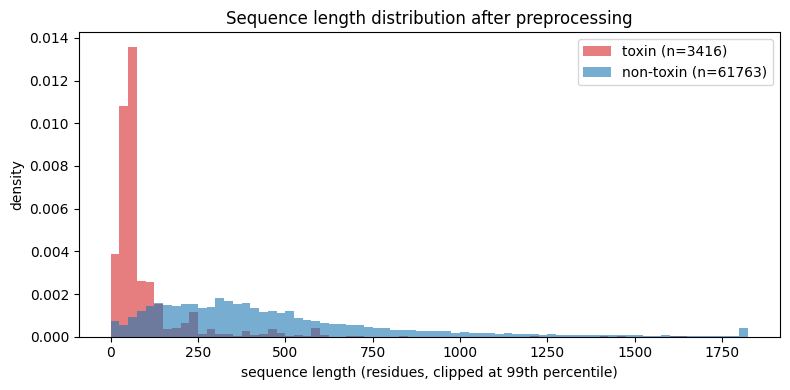

In [4]:
upper = int(max(tox_lengths.quantile(0.99), nontox_lengths.quantile(0.99)))
bins = range(0, upper + 25, 25)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    tox_lengths.clip(upper=upper),
    bins=bins,
    alpha=0.6,
    label=f"toxin (n={len(tox_lengths)})",
    density=True,
    color="tab:red",
)
ax.hist(
    nontox_lengths.clip(upper=upper),
    bins=bins,
    alpha=0.6,
    label=f"non-toxin (n={len(nontox_lengths)})",
    density=True,
    color="tab:blue",
)
ax.set_xlabel("sequence length (residues, clipped at 99th percentile)")
ax.set_ylabel("density")
ax.set_title("Sequence length distribution after preprocessing")
ax.legend()
fig.tight_layout()
plt.show()